In [1]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_auc_score
)

# 재현성 고정
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 1. 데이터 전처리 및 3분할 (Train/Val/Test)

베이스라인은 Train/Test 2분할이라 학습 중 모델 상태를 모니터링할 수 없었다. **Early Stopping과 임계값 튜닝을 위해 Val 세트를 분리**한다.

- **분할 비율**: 70% / 15% / 15% (`stratify=y`로 클래스 비율 유지)
- **스케일링**: `fit_transform`은 학습 데이터에만 적용 → Val/Test에는 `transform`만 사용 (데이터 누수 방지)

In [2]:
# 1. 데이터 로드
df = pd.read_csv('final_hybrid_data.csv')
X = df.drop('target_label', axis=1).values
y = df['target_label'].values

# 1차 분할: (Train+Val) vs Test = 85 : 15
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# 2차 분할: Train vs Val = 70 : 15 (전체 기준)
# 0.85 * 0.1765 ≈ 0.15 이므로 test_size=0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)

# 표준화 (학습 데이터에만 fit)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | class dist: {np.bincount(y_train)}")
print(f"Val  : {X_val.shape} | class dist: {np.bincount(y_val)}")
print(f"Test : {X_test.shape} | class dist: {np.bincount(y_test)}")

Train: (3882, 148) | class dist: [2622 1260]
Val  : (833, 148) | class dist: [563 270]
Test : (833, 148) | class dist: [563 270]


# 2. Dataset & DataLoader

베이스라인과 동일하지만, 검증용 `val_loader`가 추가된다. 학습 데이터만 `shuffle=True`로 설정하고 검증/테스트는 셔플하지 않는다.

In [3]:
class ReviewDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = ReviewDataset(X_train, y_train)
val_dataset   = ReviewDataset(X_val, y_val)
test_dataset  = ReviewDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. 모델 아키텍처 (BatchNorm + 강화된 Dropout)

베이스라인은 학습 Loss가 0.48 → 0.15로 빠르게 떨어졌으나 검증 F1은 낮았다. 전형적인 **과적합 신호**이므로 정규화를 강화한다.

- **BatchNorm1d**: 각 Linear 층 뒤에 추가 → 학습 안정화 + 일반화 성능 향상
- **Dropout 0.2 → 0.4**: 더 강한 정규화
- 출력층은 그대로 2개 노드 (CrossEntropyLoss와 호환)

In [4]:
class FakeReviewClassifier(nn.Module):
    def __init__(self, input_dim, dropout=0.4):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 2)  # 이진 분류 (정상: 0, 오염: 1)
        )

    def forward(self, x):
        return self.layers(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

input_dim = X_train.shape[1]
model = FakeReviewClassifier(input_dim).to(device)
print(model)

Using device: cpu
FakeReviewClassifier(
  (layers): Sequential(
    (0): Linear(in_features=148, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)


# 4. 학습 설정 — 핵심 불균형 보정

## ① Weighted CrossEntropyLoss
`compute_class_weight('balanced')`는 다음 공식으로 가중치를 자동 계산한다:

$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_c}$$

소수 클래스(오염 리뷰)에 더 큰 페널티가 부여되어 모델이 이를 무시하지 못하게 한다.

## ② AdamW + Weight Decay
Adam에 L2 정규화를 분리해 적용한 옵티마이저. `weight_decay=1e-4`로 가중치 폭주 억제.

## ③ ReduceLROnPlateau
Val F1이 3 에폭 연속 개선되지 않으면 학습률을 절반으로 감소.

In [5]:
# 클래스 가중치 자동 계산 (학습 데이터 기준)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: class 0 = {class_weights[0]:.4f}, class 1 = {class_weights[1]:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

Class weights: class 0 = 0.7403, class 1 = 1.5405


# 5. 학습 루프 — Early Stopping

매 에폭 끝에 검증 세트의 F1을 측정하여:
- **개선되면**: 모델 가중치 저장 (best state)
- **`patience` 에폭 동안 개선 없으면**: 학습 조기 종료

이렇게 하면 고정 epoch보다 안정적으로 최적 시점에서 학습이 멈춘다.

In [6]:
MAX_EPOCHS = 50
PATIENCE = 7

best_val_f1 = 0.0
best_state = None
no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(1, MAX_EPOCHS + 1):
    # ---- Train ----
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())
    val_loss /= len(val_loader)
    val_f1 = f1_score(val_true, val_preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | LR: {current_lr:.1e}")

    # ---- Early Stopping ----
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\n>>> Early stopping at epoch {epoch} (best Val F1 = {best_val_f1:.4f})")
            break

# Best 모델 복원
model.load_state_dict(best_state)
print(f"\nBest model loaded. Best Val F1 = {best_val_f1:.4f}")

Epoch   1 | Train Loss: 0.7233 | Val Loss: 0.6846 | Val F1: 0.4026 | LR: 1.0e-03
Epoch   2 | Train Loss: 0.6727 | Val Loss: 0.6801 | Val F1: 0.4425 | LR: 1.0e-03
Epoch   3 | Train Loss: 0.6554 | Val Loss: 0.6837 | Val F1: 0.4229 | LR: 1.0e-03
Epoch   4 | Train Loss: 0.6418 | Val Loss: 0.6841 | Val F1: 0.4156 | LR: 1.0e-03
Epoch   5 | Train Loss: 0.6243 | Val Loss: 0.6989 | Val F1: 0.4444 | LR: 1.0e-03
Epoch   6 | Train Loss: 0.6138 | Val Loss: 0.7020 | Val F1: 0.4358 | LR: 1.0e-03
Epoch   7 | Train Loss: 0.5907 | Val Loss: 0.7077 | Val F1: 0.4465 | LR: 1.0e-03
Epoch   8 | Train Loss: 0.5736 | Val Loss: 0.7022 | Val F1: 0.4547 | LR: 1.0e-03
Epoch   9 | Train Loss: 0.5662 | Val Loss: 0.7225 | Val F1: 0.4361 | LR: 1.0e-03
Epoch  10 | Train Loss: 0.5573 | Val Loss: 0.7361 | Val F1: 0.4601 | LR: 1.0e-03
Epoch  11 | Train Loss: 0.5371 | Val Loss: 0.7318 | Val F1: 0.4444 | LR: 1.0e-03
Epoch  12 | Train Loss: 0.5168 | Val Loss: 0.7425 | Val F1: 0.4557 | LR: 1.0e-03
Epoch  13 | Train Loss: 0.49

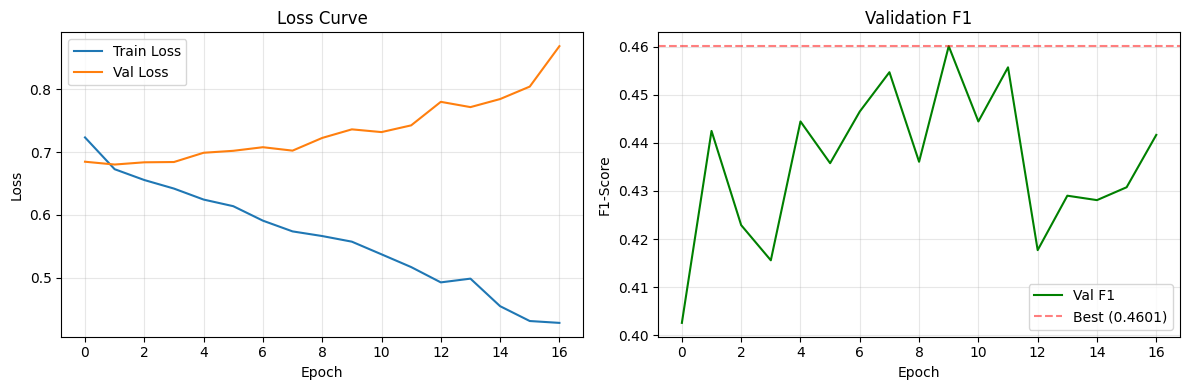

In [7]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_f1'], color='green', label='Val F1')
axes[1].axhline(best_val_f1, ls='--', color='red', alpha=0.5, label=f'Best ({best_val_f1:.4f})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1-Score')
axes[1].set_title('Validation F1'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# 6. 임계값(Threshold) 튜닝

기본값 0.5는 균형 잡힌 데이터를 가정한다. 불균형 데이터에서는 **임계값을 낮추면 Recall이 올라간다**.

Precision-Recall 곡선의 모든 후보 임계값을 검토하여 **검증 세트에서 F1을 최대화하는 값**을 선택한다.

> ⚠️ **데이터 누수 방지**: 임계값은 반드시 검증 세트에서 결정하고, 테스트 세트에는 그 값을 그대로 적용한다.

Best threshold (val): 0.0550
At this threshold → Precision: 0.3288, Recall: 0.9926, F1: 0.4940


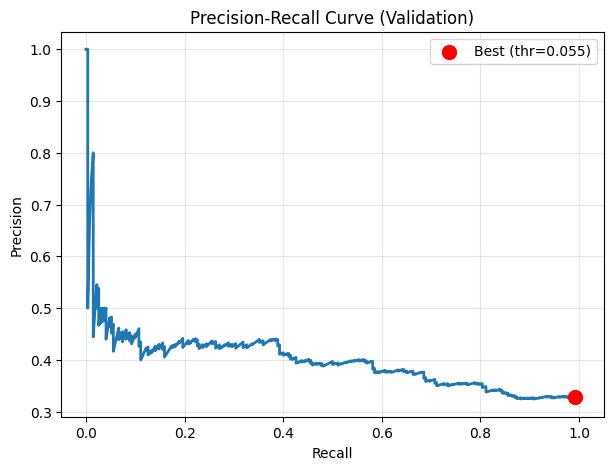

In [8]:
def get_probs(loader):
    """클래스 1(오염)에 대한 확률 반환"""
    model.eval()
    probs, true = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            p = torch.softmax(outputs, dim=1)[:, 1]
            probs.extend(p.cpu().numpy())
            true.extend(labels.numpy())
    return np.array(probs), np.array(true)

val_probs, val_true = get_probs(val_loader)

precisions, recalls, thresholds = precision_recall_curve(val_true, val_probs)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
# precision_recall_curve는 마지막 점에 threshold가 없으므로 제외
best_idx = np.argmax(f1s[:-1])
best_threshold = thresholds[best_idx]

print(f"Best threshold (val): {best_threshold:.4f}")
print(f"At this threshold → Precision: {precisions[best_idx]:.4f}, "
      f"Recall: {recalls[best_idx]:.4f}, F1: {f1s[best_idx]:.4f}")

# PR 곡선 시각화
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, lw=2)
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', s=100, zorder=5,
            label=f'Best (thr={best_threshold:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Validation)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# 7. 최종 평가 (Test Set)

두 가지 임계값 결과를 비교한다.

- **기본 0.5**: 베이스라인과 직접 비교용
- **튜닝된 임계값**: 실제 운영 시 사용할 값

추가 지표로 **PR-AUC** 출력 — 불균형 데이터에서는 ROC-AUC보다 신뢰성이 높다.

In [9]:
test_probs, test_true = get_probs(test_loader)

preds_default = (test_probs >= 0.5).astype(int)
preds_tuned   = (test_probs >= best_threshold).astype(int)

print("=" * 60)
print(f"  [A] Default Threshold = 0.5")
print("=" * 60)
print(classification_report(test_true, preds_default, digits=4,
                            target_names=['정상(0)', '오염(1)']))

print("=" * 60)
print(f"  [B] Tuned Threshold = {best_threshold:.4f}")
print("=" * 60)
print(classification_report(test_true, preds_tuned, digits=4,
                            target_names=['정상(0)', '오염(1)']))

print("=" * 60)
print("  [C] AUC Metrics")
print("=" * 60)
print(f"  ROC-AUC : {roc_auc_score(test_true, test_probs):.4f}")
print(f"  PR-AUC  : {average_precision_score(test_true, test_probs):.4f}  (불균형 데이터에 더 적합)")

print("\n  F1 비교")
print(f"  - threshold 0.5  → F1 = {f1_score(test_true, preds_default):.4f}")
print(f"  - threshold {best_threshold:.3f} → F1 = {f1_score(test_true, preds_tuned):.4f}")

  [A] Default Threshold = 0.5
              precision    recall  f1-score   support

       정상(0)     0.7391    0.6643    0.6997       563
       오염(1)     0.4220    0.5111    0.4623       270

    accuracy                         0.6146       833
   macro avg     0.5806    0.5877    0.5810       833
weighted avg     0.6363    0.6146    0.6228       833

  [B] Tuned Threshold = 0.0550
              precision    recall  f1-score   support

       정상(0)     0.9231    0.0213    0.0417       563
       오염(1)     0.3280    0.9963    0.4936       270

    accuracy                         0.3373       833
   macro avg     0.6256    0.5088    0.2676       833
weighted avg     0.7302    0.3373    0.1881       833

  [C] AUC Metrics
  ROC-AUC : 0.6147
  PR-AUC  : 0.4281  (불균형 데이터에 더 적합)

  F1 비교
  - threshold 0.5  → F1 = 0.4623
  - threshold 0.055 → F1 = 0.4936


/var/folders/wq/j2lqqp7n33dgrwj1r4q0nl9m0000gn/T/ipykernel_17956/1656281083.py:18: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/wq/j2lqqp7n33dgrwj1r4q0nl9m0000gn/T/ipykernel_17956/1656281083.py:18: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/wq/j2lqqp7n33dgrwj1r4q0nl9m0000gn/T/ipykernel_17956/1656281083.py:18: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/wq/j2lqqp7n33dgrwj1r4q0nl9m0000gn/T/ipykernel_17956/1656281083.py:18: UserWarning: Glyph 50684 (\N{HANGUL SYLLABLE YEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/hyunseop/Developer/uni/big-data/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
 

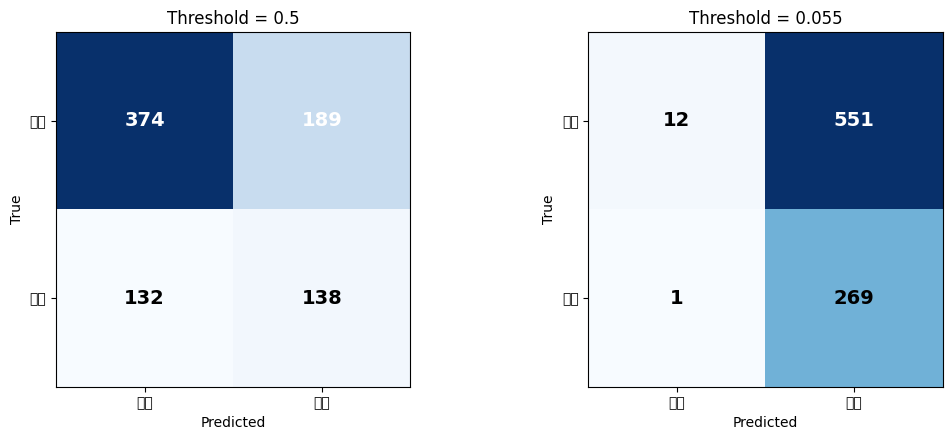

In [10]:
# Confusion Matrix 시각화
cm_default = confusion_matrix(test_true, preds_default)
cm_tuned   = confusion_matrix(test_true, preds_tuned)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in zip(axes, [cm_default, cm_tuned],
                          [f'Threshold = 0.5', f'Threshold = {best_threshold:.3f}']):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['정상', '오염']); ax.set_yticklabels(['정상', '오염'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black',
                    fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 🧪 결과 분석 가이드

결과 해석 시 점검할 항목:

1. **클래스 1(오염) Recall 변화**: 베이스라인 0.32에서 얼마나 올랐는가?
2. **임계값 튜닝 효과**: threshold 0.5 vs 튜닝값 → F1 차이 확인
3. **PR-AUC**: F1 단일 값보다 모델 본질적 성능을 잘 반영. 0.6 이상이면 양호
4. **Train/Val Loss 격차**: 학습 곡선에서 두 곡선이 크게 벌어지면 여전히 과적합

### 추가 개선 옵션
- **여전히 Recall 부족**: `class_weight`에 수동 가중치 적용 (예: `[1.0, 2.5]`)
- **오버피팅 지속**: Dropout 0.5로 추가 강화, hidden dim 축소(128→64)
- **Focal Loss**: 어려운 샘플에 집중 — 매우 심한 불균형(1:10 이상)에서 효과적
- **SMOTE**: KcBERT 임베딩 같은 고차원 공간에서는 합성 품질이 떨어질 수 있어 신중히 사용